In [1]:
# Importing the Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn import svm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

In [2]:
# loading the dataset
dataset = pd.read_excel('tunnel.xlsx')

# Display the first few rows to explore the dataset
dataset.head()

,CRS,T,PRchd,F,PRnet,RMC
0,7.0,330.0,9.73,2900.0,67.0,IV
1,7.0,335.0,9.80,3075.0,68.0,IV
2,7.0,334.5,9.70,3100.0,68.0,IV
3,7.0,300.0,10.00,3115.0,72.5,IV
4,7.2,305.0,11.00,2650.0,72.5,IV


In [3]:
dataset['RMC'].value_counts()

IV     4543
III    2164
V       172
Name: RMC, dtype: int64

In [4]:
# Encode the target variable
encoder = LabelEncoder()
dataset['RMC'] = encoder.fit_transform(dataset['RMC'])
# Store the original class names for later use
original_class_names = encoder.classes_

In [5]:
# Prepare Features and Target
X = dataset.drop(columns='RMC', axis=1)
Y = dataset['RMC']

# Train Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)


# Scale Features
scaler = RobustScaler()
scaler.fit(X_train)  # Fit on the training data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)



# Create SVM classifier with chosen hyperparameters
classifier = svm.SVC(C=40, kernel='rbf', gamma='scale')  # You can adjust C, kernel, and gamma as needed

# Training and Fit the model
classifier.fit(X_train_scaled, Y_train)

# Make predictions
# accuracy score on the training data
Y_train_pred = classifier.predict(X_train_scaled)
training_data_accuracy = accuracy_score(Y_train, Y_train_pred).round(3)
print('Accuracy score of the training data: ', training_data_accuracy)


Accuracy score of the training data:  0.873


In [6]:
# accuracy score on the test data
Y_pred = classifier.predict(X_test_scaled)
# Decode the predicted labels to their original values
Y_pred_decoded = encoder.inverse_transform(Y_pred)
Y_test_decoded = encoder.inverse_transform(Y_test)

test_data_accuracy = accuracy_score(Y_test_decoded, Y_pred_decoded).round(3)
print('Accuracy score of the test data: ', test_data_accuracy)

Accuracy score of the test data:  0.876


In [7]:
# Evaluate the model
print("Accuracy:", accuracy_score(Y_test_decoded, Y_pred_decoded))
print("Classification Report:\n", classification_report(Y_test_decoded, Y_pred_decoded))
print("Confusion Matrix:\n", confusion_matrix(Y_test_decoded, Y_pred_decoded))

Accuracy: 0.876453488372093
Classification Report:
               precision    recall  f1-score   support

         III       0.83      0.83      0.83       433
          IV       0.90      0.92      0.91       909
           V       0.79      0.32      0.46        34

    accuracy                           0.88      1376
   macro avg       0.84      0.69      0.73      1376
weighted avg       0.87      0.88      0.87      1376

Confusion Matrix:
 [[360  73   0]
 [ 71 835   3]
 [  1  22  11]]


## Confusion Matrix Visualization

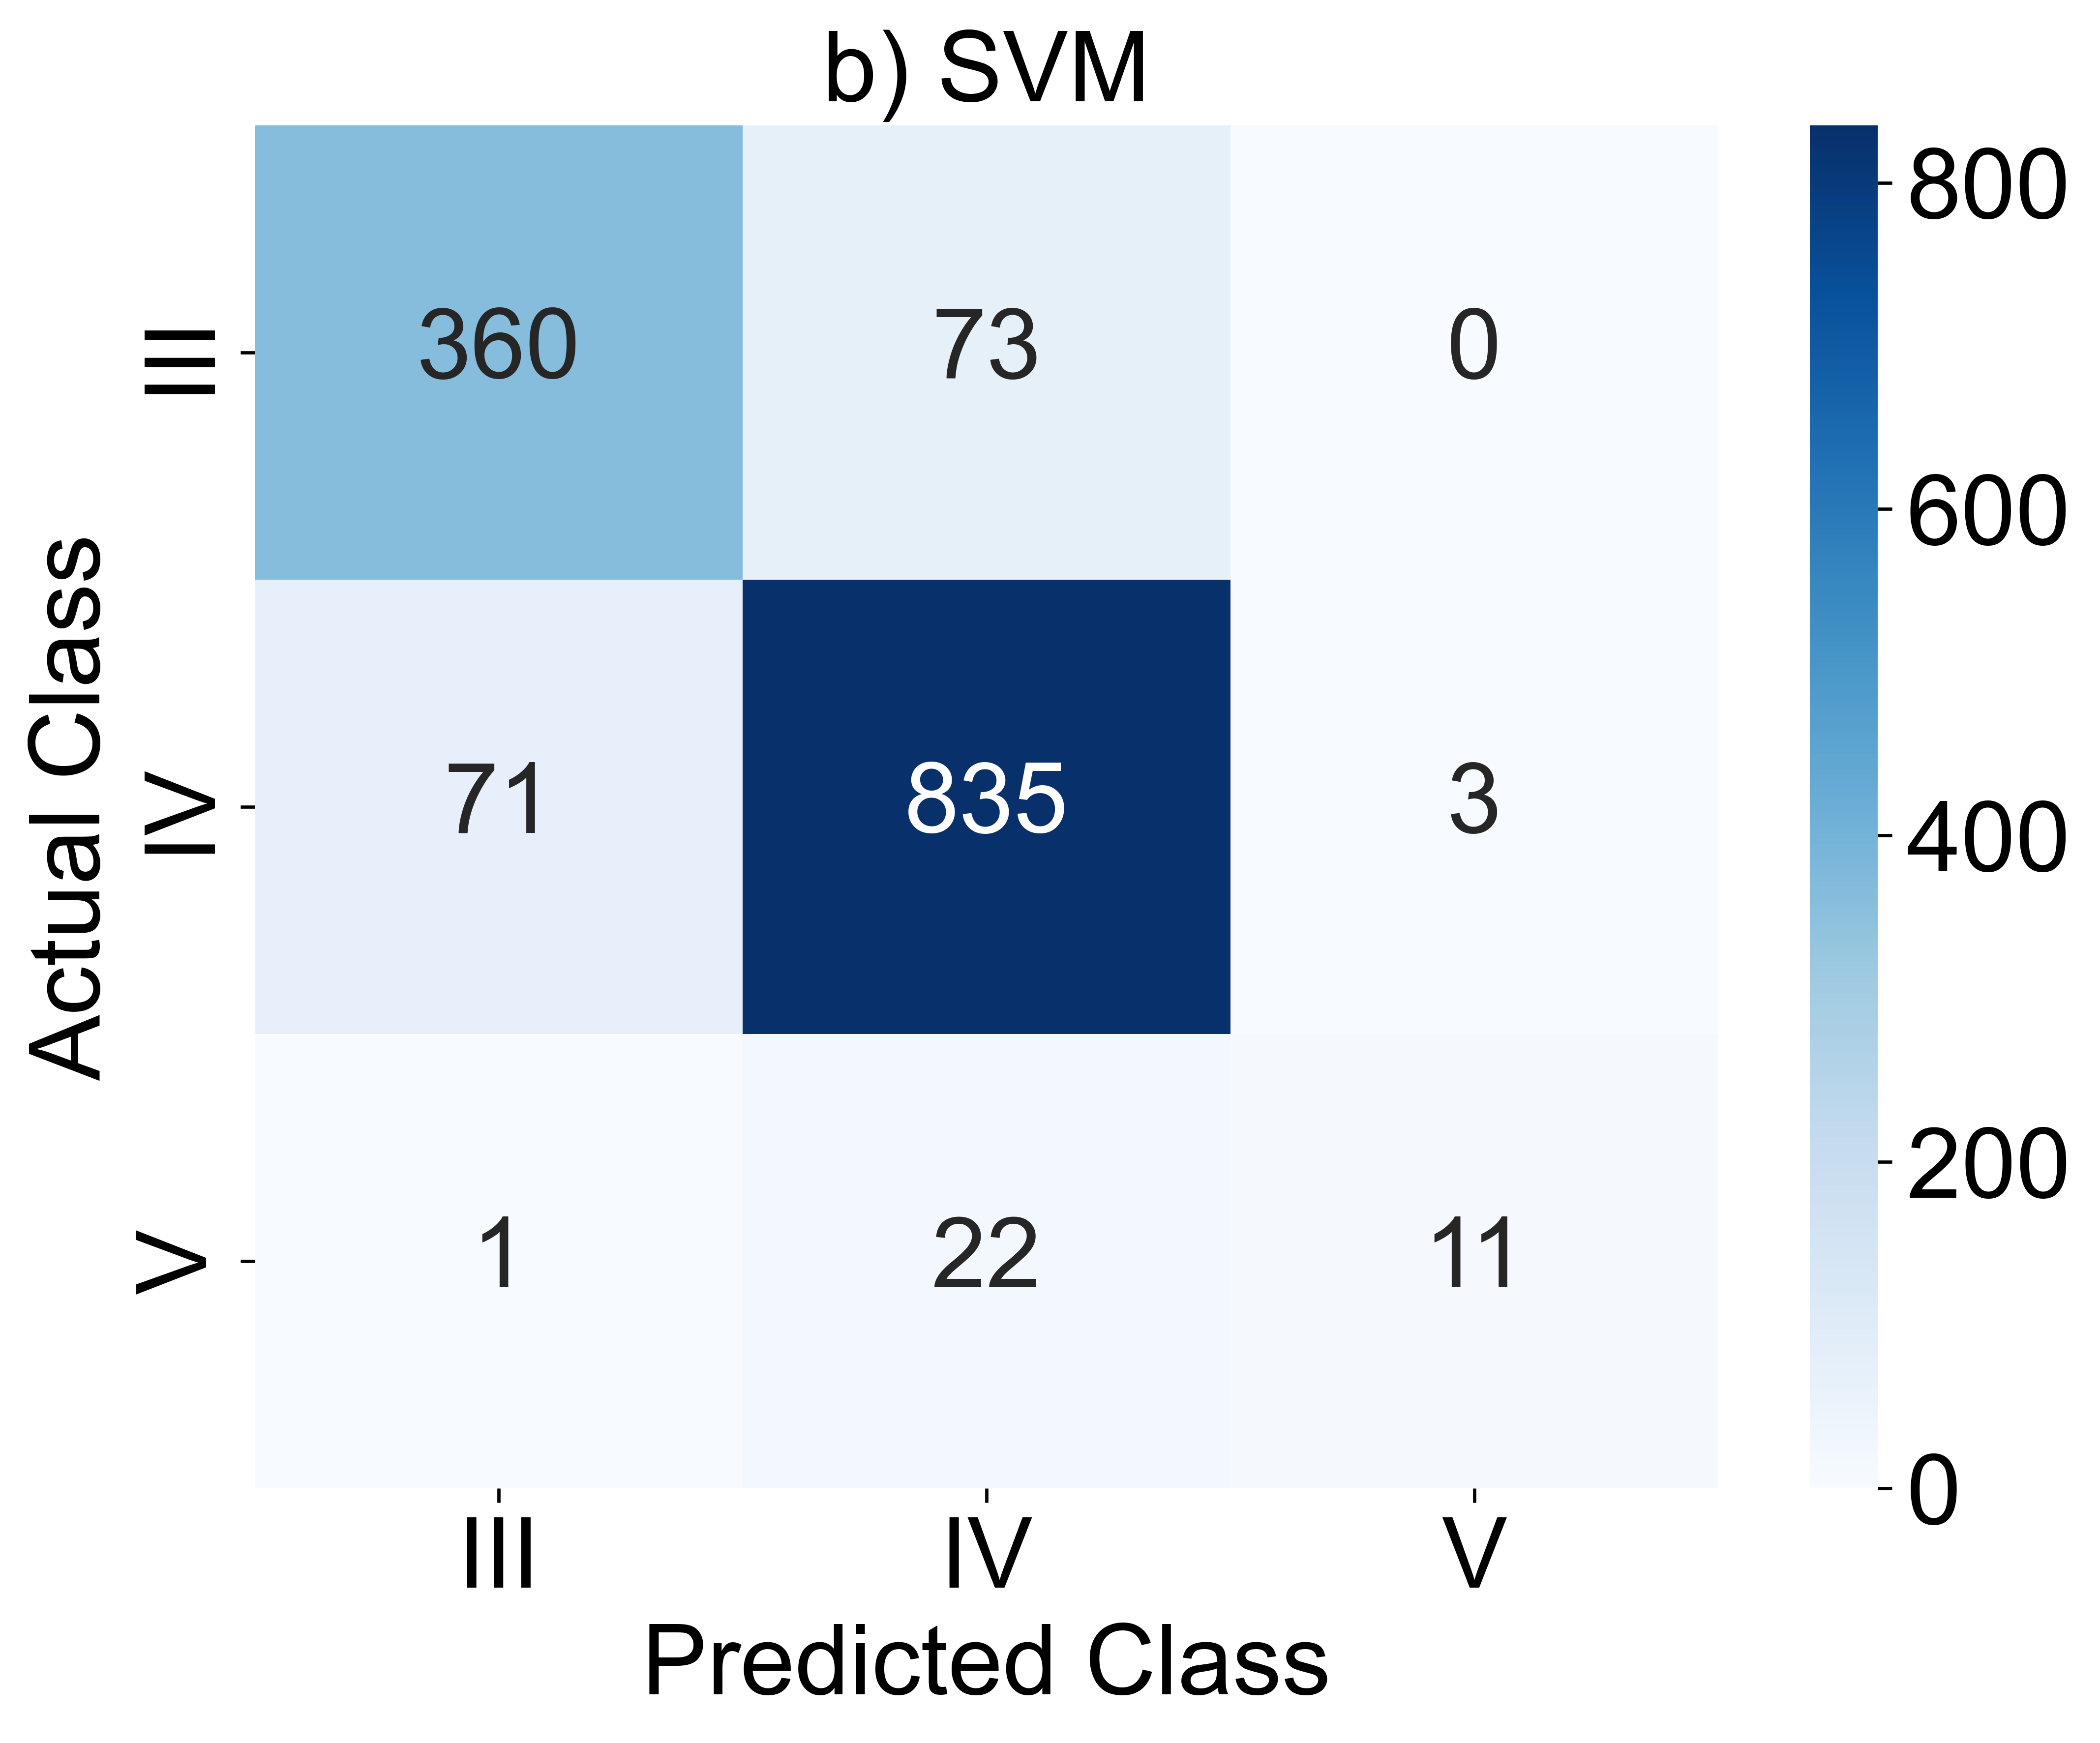

In [8]:
# Set font to Times New Roman
plt.rcParams['font.family'] = 'Arial'

# Plot the confusion matrix heatmap
plt.figure(figsize=(8, 6),dpi=600)

# Confusion Matrix
conf_matrix = confusion_matrix(Y_test_decoded, Y_pred_decoded)
heatmap = sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=original_class_names, yticklabels=original_class_names,annot_kws={"size": 24})
plt.title('b) SVM', fontsize=24)
plt.xlabel('Predicted Class',fontsize=24)
plt.ylabel('Actual Class', fontsize=24)
# Increase x and y label size
heatmap.set_xticklabels(heatmap.get_xticklabels(), fontsize=24)
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=24)

# Get the colorbar axes and set the label size
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=24) 

plt.show()

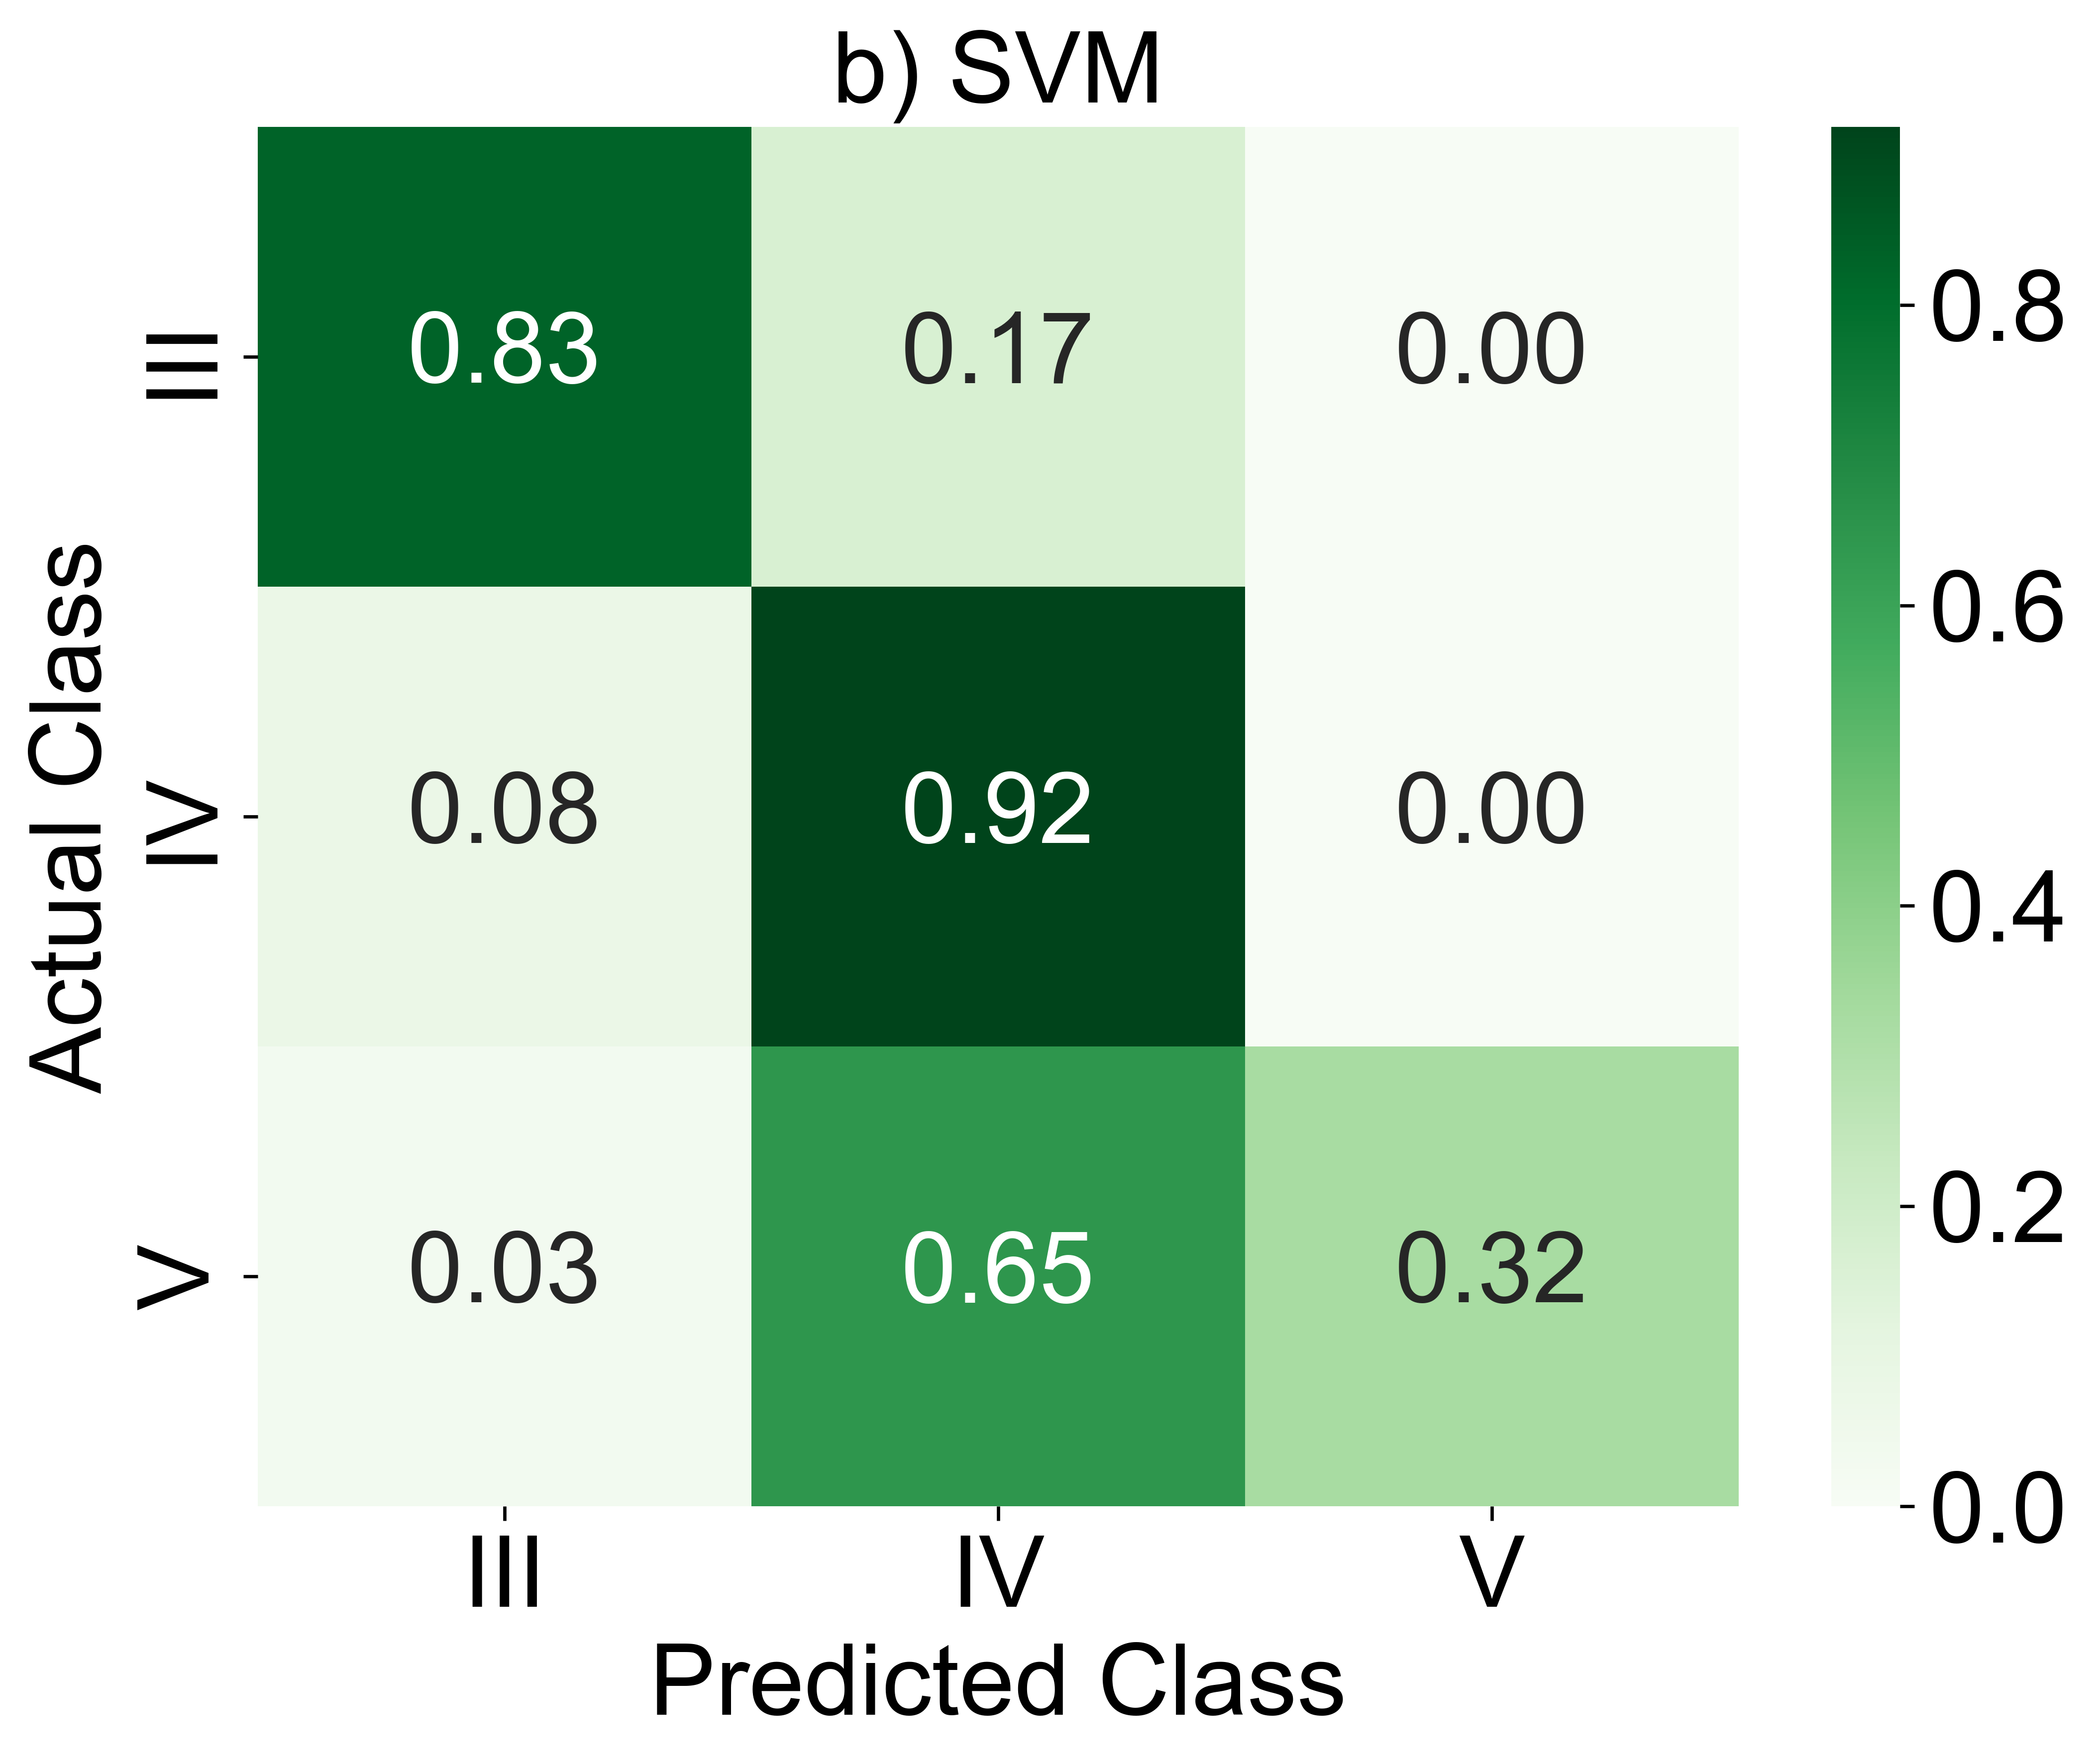

In [9]:
# Set font to Times New Roman
plt.rcParams['font.family'] = 'Arial'

# Calculate percentages
conf_matrix_percent = conf_matrix / conf_matrix.sum(axis=1, keepdims=True)

# Plot the confusion matrix heatmap with percentages as decimals
plt.figure(figsize=(8, 6),dpi=600)
heatmap = sns.heatmap(conf_matrix_percent, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=original_class_names, yticklabels=original_class_names, annot_kws={"size": 24})
plt.title('b) SVM', fontsize=24)
plt.xlabel('Predicted Class', fontsize=24)
plt.ylabel('Actual Class', fontsize=24)
# Increase x and y label size
heatmap.set_xticklabels(heatmap.get_xticklabels(), fontsize=24)
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=24)
# Get the colorbar axes and set the label size
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=24) #[delet # if you need cbar as well, otherwise use remoce the color bar code which is in below]
plt.show()

# ROC Curve Visualization

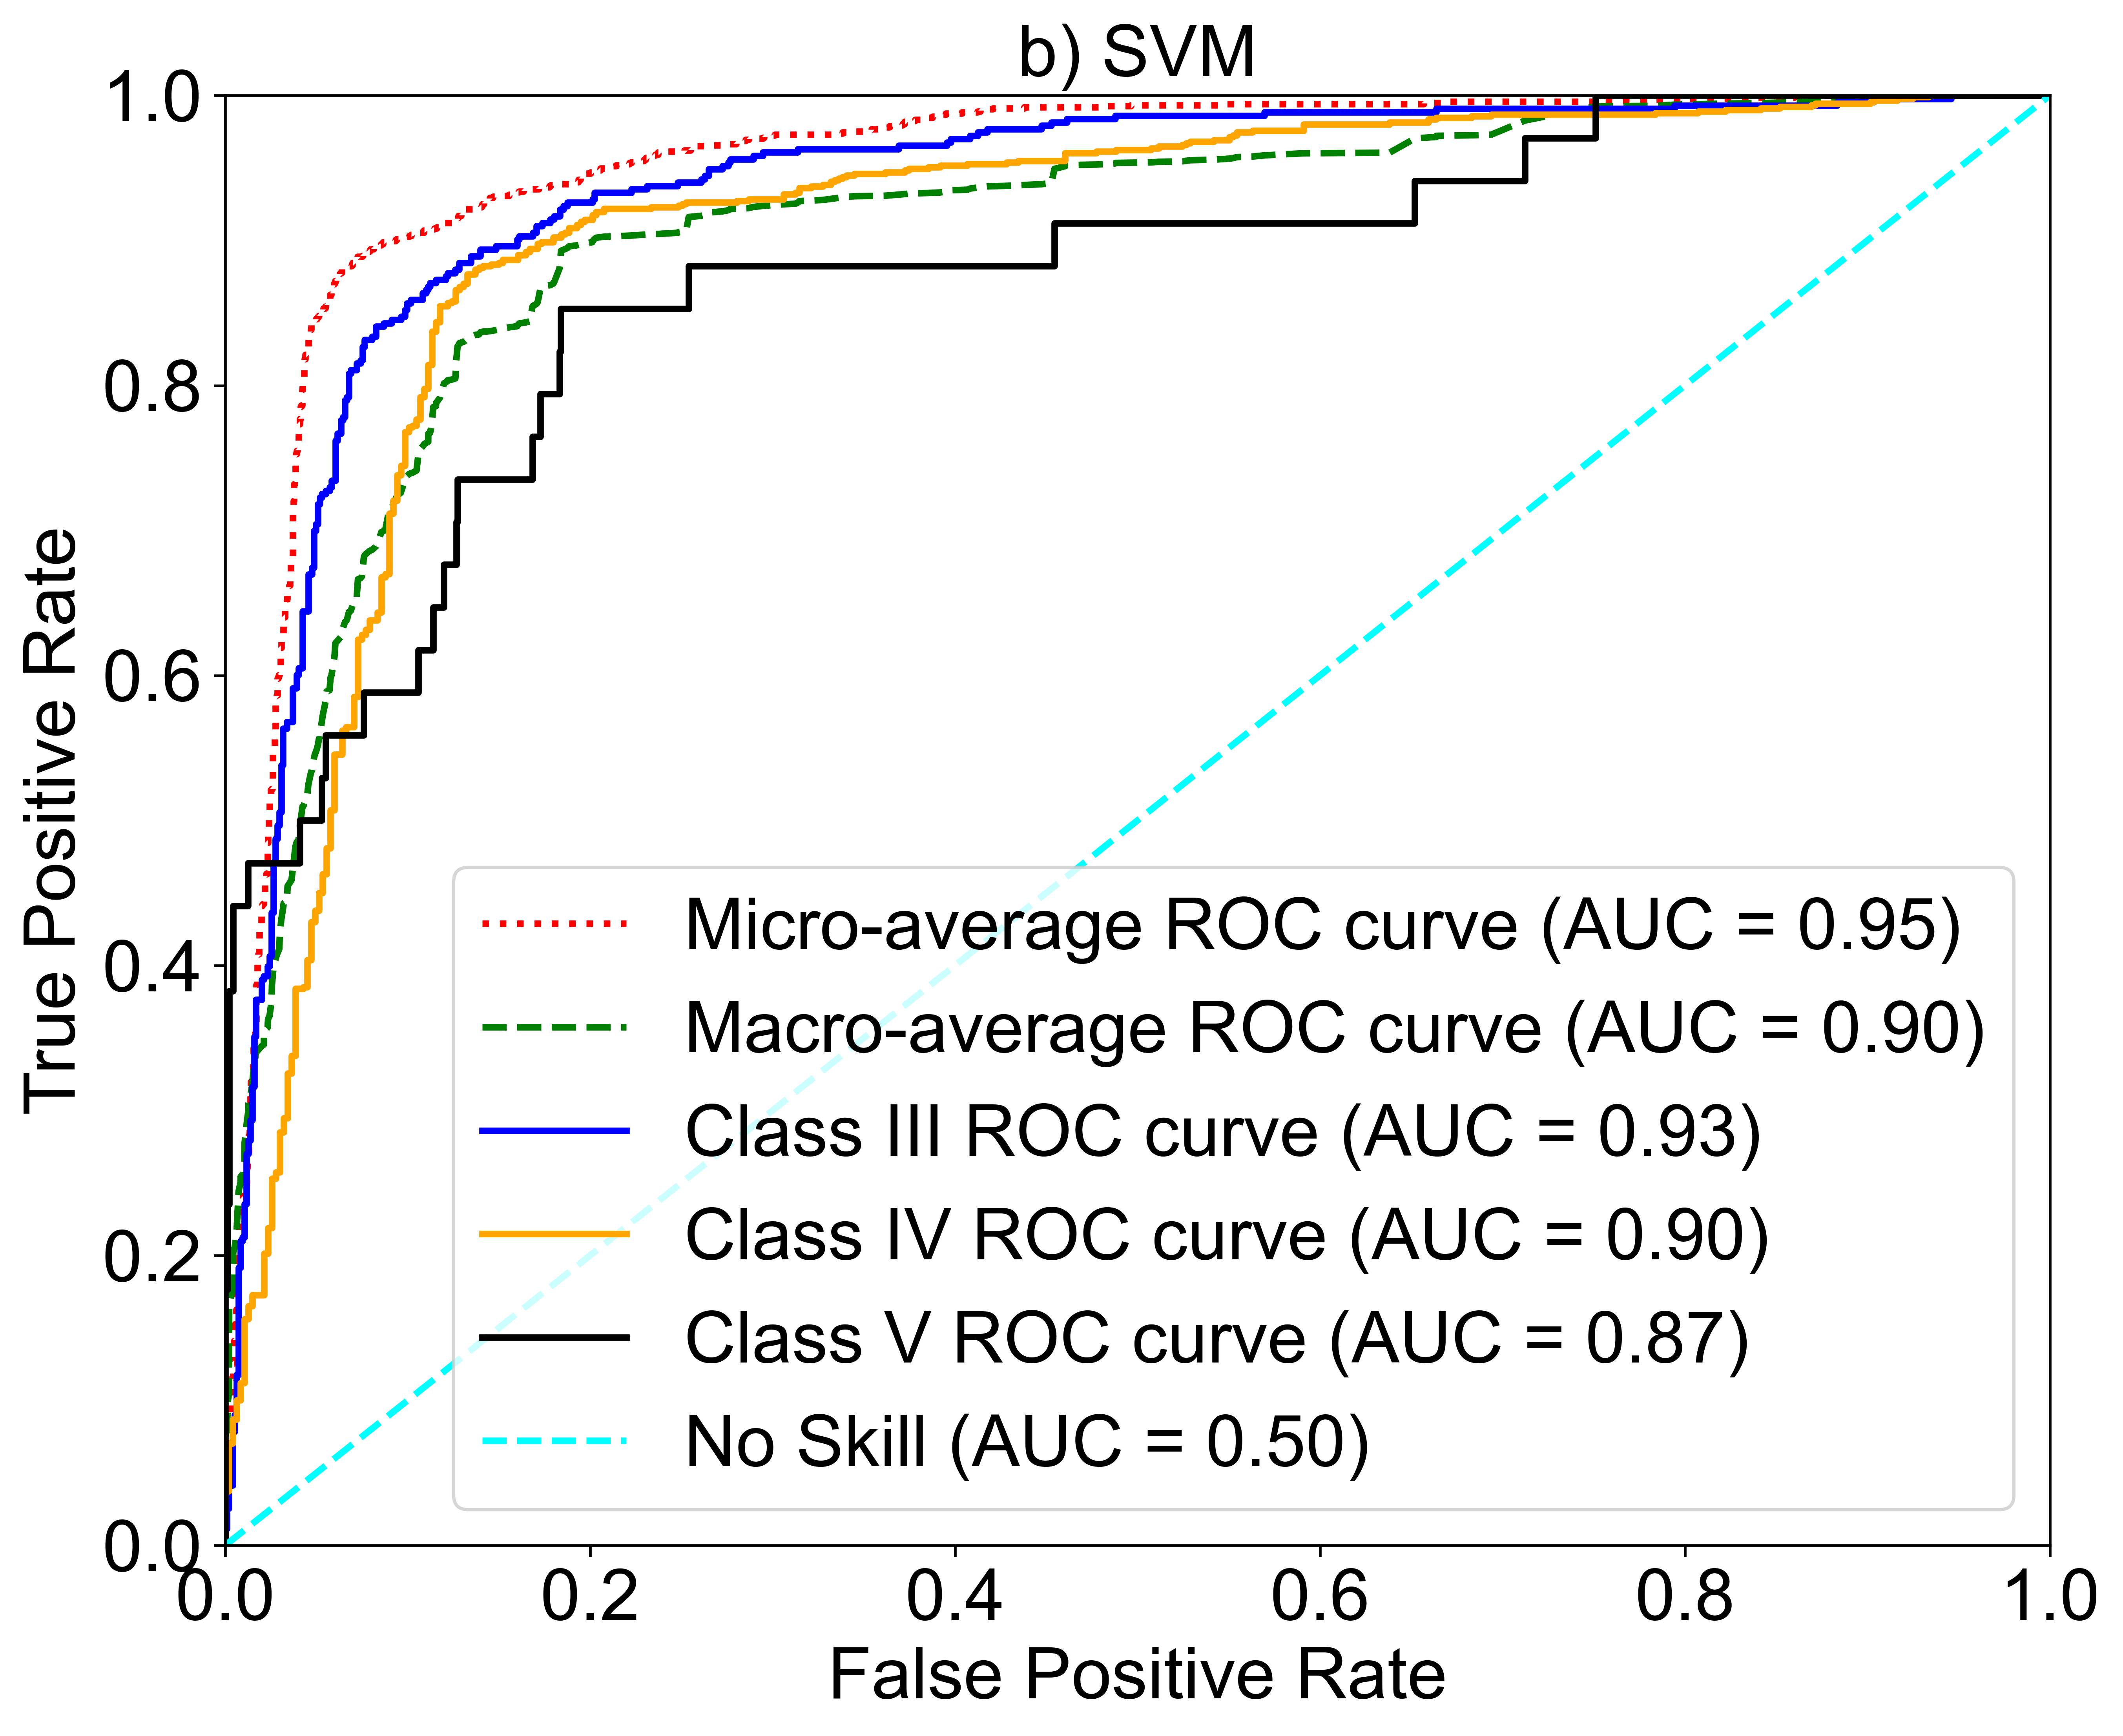

In [10]:
# Set font to Times New Roman
plt.rcParams['font.family'] = 'Arial'

# Model Evaluation
Y_pred_proba = classifier.decision_function(X_test_scaled)
n_classes = len(encoder.classes_)

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

# Adjustments for original class names in ROC computation
for i, class_label in enumerate(encoder.classes_):  # Use original class names
    binary_true_labels = (Y_test == i).astype(int)  # Y_test is already encoded
    fpr[class_label], tpr[class_label], thresholds = roc_curve(binary_true_labels, Y_pred_proba[:, i])
    roc_auc[class_label] = auc(fpr[class_label], tpr[class_label])

# Compute micro-average ROC curve and AUC
fpr_micro, tpr_micro, thresholds = roc_curve(pd.get_dummies(Y_test).values.ravel(), 
                                                   Y_pred_proba.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

# Compute macro-average ROC curve and AUC
all_fpr = np.unique(np.concatenate([fpr[cls] for cls in encoder.classes_]))
mean_tpr = np.zeros_like(all_fpr)
for cls in encoder.classes_:
    mean_tpr += np.interp(all_fpr, fpr[cls], tpr[cls])
mean_tpr /= n_classes
fpr_macro = all_fpr
tpr_macro = mean_tpr
roc_auc_macro = auc(fpr_macro, tpr_macro)



# Define colors and line styles
class_colors = {'III': 'blue', 'IV': 'orange', 'V': 'black'}
class_linestyles = {'III': '-', 'IV': '-', 'V': '-'}
macro_color = 'green'
micro_color = 'red'
macro_linestyle = '--'
micro_linestyle = ':'
no_skill_label = 'No Skill'
no_skill_color = 'cyan'

# Plot ROC curves with custom colors and line styles
plt.figure(figsize=(10, 8), dpi=600)
plt.plot(fpr_micro, tpr_micro, label=f'Micro-average ROC curve (AUC = {roc_auc_micro:.2f})',
         color=micro_color, linestyle=micro_linestyle, linewidth=2)
plt.plot(fpr_macro, tpr_macro, label=f'Macro-average ROC curve (AUC = {roc_auc_macro:.2f})',
         color=macro_color, linestyle=macro_linestyle, linewidth=2)

for cls in encoder.classes_:
    plt.plot(fpr[cls], tpr[cls], label=f'Class {cls} ROC curve (AUC = {roc_auc[cls]:.2f})',
             color=class_colors[cls], linestyle=class_linestyles[cls], linewidth=2)



# Plot the "No Skill" line
plt.plot([0, 1], [0, 1], color=no_skill_color, linestyle='--', label=f'{no_skill_label} (AUC = 0.50)', linewidth=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])

plt.xlabel('False Positive Rate', fontsize=22)
plt.ylabel('True Positive Rate', fontsize=22)
plt.title('b) SVM', fontsize=22)  # You can change the title if needed

# Set tick label size
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

# Set legend
plt.legend(loc='lower right', fontsize=22)

# Show the plot
plt.show()